
File: GrossWasserkraft.csv
Shape: (8760, 65)
Columns: ['Zeitpunkt', '1040', '2001', '2005', '2010', '2020', '2027', '2071', '3001', '3003', '3013', '23015', '23019', '3041', '3047', '3049', '3052', '3057', '23063', '3063', '3072', '3089', '3090', '3101', '3513', '3518', '23520', '5007', '5011', '5016', '5026', '5027', '5028', '6009', '6026', '7001', '7011', '7015', '7020', '7023', '7055', '7062', '7501', '7502', '7506', '8028', '8029', '8033', '8040', '8045', '8052', '8056', '8057', '8064', '8075', '8090', '9001', '9012', '9030', '9037', '9039', '9041', '9043', '9050', '9062']
Head:
          Zeitpunkt      1040      2001      2005      2010      2020  \
0  01.01.2023 00:00  0.071136  0.004806  0.152503  0.107154  0.004581   
1  01.01.2023 01:00  0.088974  0.006667  0.171887  0.111875  0.004581   
2  01.01.2023 02:00  0.092583  0.010476  0.171887  0.111875  0.004581   
3  01.01.2023 03:00  0.092583  0.013991  0.171887  0.111875  0.004581   
4  01.01.2023 04:00  0.092583  0.013991  0.1

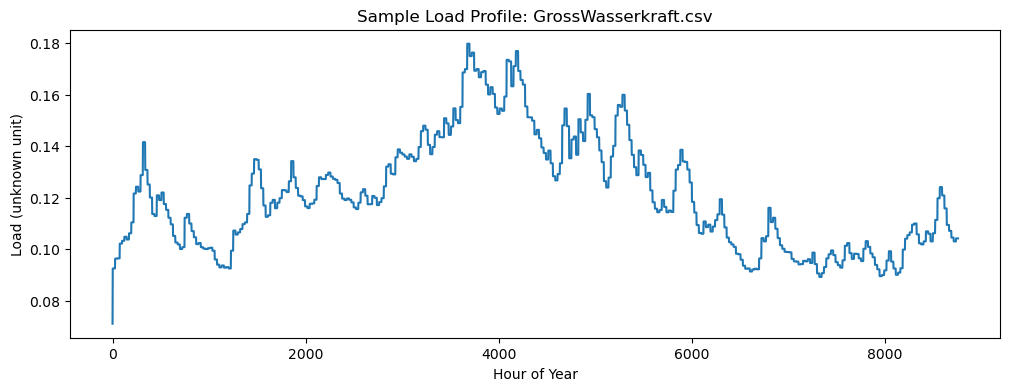

In [2]:
import os
import pandas as pd

import matplotlib.pyplot as plt

# Directory containing the load profile files
data_dir = "../data/MA/loads/NIP2030"

# List all files in the directory
files = [f for f in os.listdir(data_dir) if os.path.isfile(os.path.join(data_dir, f))]

# Read all files into a dictionary of DataFrames
load_profiles = {}
for file in files:
    file_path = os.path.join(data_dir, file)
    try:
        df = pd.read_csv(file_path, sep=";")
        load_profiles[file] = df
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Analyze structure and consistency
for name, df in load_profiles.items():
    print(f"\nFile: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Head:\n{df.head()}")
    print(f"Describe:\n{df.describe()}")

# Check if all files have the same shape and columns
shapes = [df.shape for df in load_profiles.values()]
columns = [tuple(df.columns) for df in load_profiles.values()]
print("\nAll shapes:", set(shapes))
print("All columns:", set(columns))

# Try to infer units by inspecting values
for name, df in load_profiles.items():
    print(f"\nFile: {name}")
    # Skip the first column (Zeitpunkt), show stats for the first data column
    first_data_col = df.columns[1]
# Plot a sample profile for visual inspection
sample_file = list(load_profiles.keys())[0]
sample_df = load_profiles[sample_file]
plt.figure(figsize=(12,4))
first_data_col = sample_df.columns[1]
plt.plot(sample_df[first_data_col].values)
plt.title(f"Sample Load Profile: {sample_file}")
plt.xlabel("Hour of Year")
plt.ylabel("Load (unknown unit)")
plt.show()

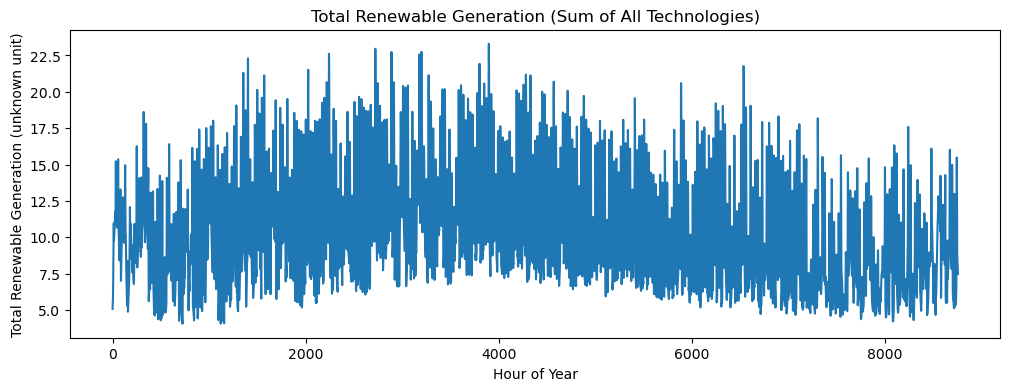

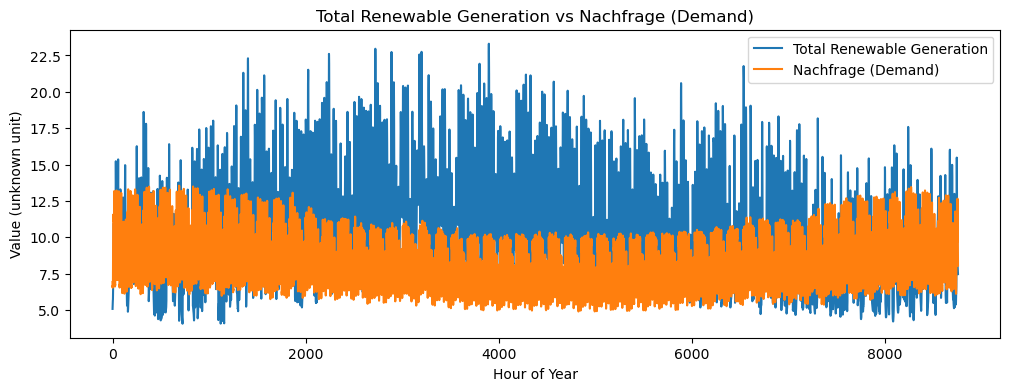

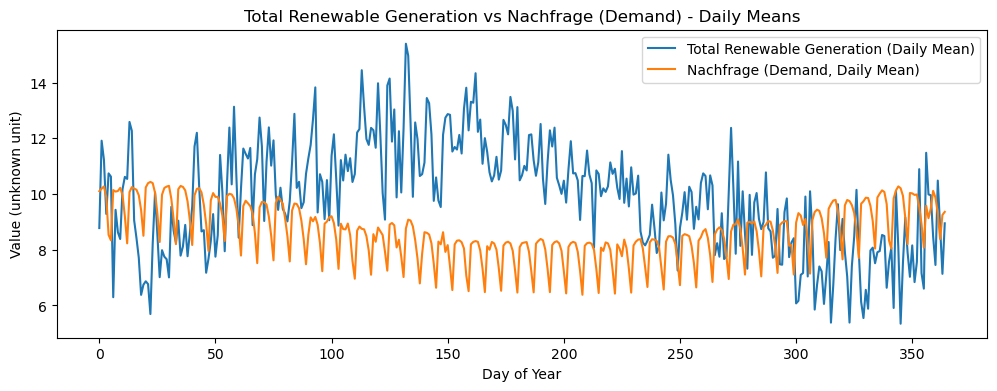

In [10]:
# List of renewable technology files (excluding 'Nachfrage.csv')
renewable_files = [f for f in files if f != 'Nachfrage.csv']

# Sum all columns (except 'Zeitpunkt') for each renewable technology and add up across all technologies
total_renewable = None
for fname in renewable_files:
    df = load_profiles[fname]
    data_cols = [col for col in df.columns if col != 'Zeitpunkt']
    summed = df[data_cols].sum(axis=1)
    if total_renewable is None:
        total_renewable = summed
    else:
        total_renewable += summed

plt.figure(figsize=(12, 4))
plt.plot(total_renewable.values)
plt.title("Total Renewable Generation (Sum of All Technologies)")
plt.xlabel("Hour of Year")
plt.ylabel("Total Renewable Generation (unknown unit)")
plt.show()

# Plot Nachfrage (demand) on the same figure for comparison
nachfrage_df = load_profiles['Nachfrage.csv']
nachfrage_cols = [col for col in nachfrage_df.columns if col != 'Zeitpunkt']
nachfrage_total = nachfrage_df[nachfrage_cols].sum(axis=1)

plt.figure(figsize=(12, 4))
plt.plot(total_renewable.values, label="Total Renewable Generation")
plt.plot(nachfrage_total.values, label="Nachfrage (Demand)")
plt.title("Total Renewable Generation vs Nachfrage (Demand)")
plt.xlabel("Hour of Year")
plt.ylabel("Value (unknown unit)")
plt.legend()
# Resample to daily means for better visualization
total_renewable_daily = total_renewable.groupby(total_renewable.index // 24).mean()
nachfrage_daily = nachfrage_total.groupby(nachfrage_total.index // 24).mean()

plt.show()

plt.figure(figsize=(12, 4))
plt.plot(total_renewable_daily.values, label="Total Renewable Generation (Daily Mean)")
plt.plot(nachfrage_daily.values, label="Nachfrage (Demand, Daily Mean)")
plt.title("Total Renewable Generation vs Nachfrage (Demand) - Daily Means")
plt.xlabel("Day of Year")
plt.ylabel("Value (unknown unit)")
plt.legend()
plt.show()

In [3]:
# Try to infer units by analyzing value ranges and column names for each file
for fname, df in load_profiles.items():
    print(f"\nFile: {fname}")
    # Exclude 'Zeitpunkt' column for stats
    data_cols = [col for col in df.columns if col != 'Zeitpunkt']
    stats = df[data_cols].describe()
    print(stats.loc[['min', 'max', 'mean']])
    # Heuristic: check if values are typically in range [0, 1], [0, 1000], etc.
    min_val = stats.loc['min'].min()
    max_val = stats.loc['max'].max()
    mean_val = stats.loc['mean'].mean()
    print(f"Value range: min={min_val}, max={max_val}, mean={mean_val}")
    if max_val < 2:
        print("Possible unit: normalized (per unit, MW/MWh per MW installed, or share)")
    elif max_val < 100:
        print("Possible unit: MW or MWh (small/medium scale)")
    elif max_val < 10000:
        print("Possible unit: MW or MWh (large scale)")
    else:
        print("Possible unit: kW, kWh, or other")


File: GrossWasserkraft.csv
          1040      2001      2005      2010      2020      2027      2071  \
min   0.071136  0.004806  0.152503  0.107154  0.003748  0.099089  0.122354   
max   0.179836  0.019625  0.336408  0.227242  0.010418  0.206873  0.295798   
mean  0.121201  0.013889  0.225799  0.149720  0.007048  0.138282  0.198967   

          3001      3003      3013  ...      8090      9001      9012  \
min   0.071434  0.009371  0.003421  ...  0.002902  0.020305  0.025702   
max   0.104464  0.035073  0.015743  ...  0.006754  0.037488  0.049998   
mean  0.087611  0.024821  0.008399  ...  0.004247  0.035882  0.047953   

          9030      9037      9039      9041      9043      9050      9062  
min   0.004482  0.027113  0.017623  0.007654  0.019013  0.004338  0.018492  
max   0.007945  0.054456  0.028426  0.008679  0.024025  0.012058  0.022226  
mean  0.007581  0.051757  0.026895  0.008009  0.020747  0.008157  0.020841  

[3 rows x 64 columns]
Value range: min=0.001434835, max=0

In [4]:
for fname, df in load_profiles.items():
    data_cols = [col for col in df.columns if col != 'Zeitpunkt']
    below_zero = (df[data_cols] < 0).any().any()
    above_one = (df[data_cols] > 1).any().any()
    print(f"{fname}: Below 0? {below_zero}, Above 1? {above_one}")

GrossWasserkraft.csv: Below 0? False, Above 1? False
Kleinwasserkraft.csv: Below 0? False, Above 1? False
Nachfrage.csv: Below 0? False, Above 1? False
PV.csv: Below 0? False, Above 1? False
Wind.csv: Below 0? False, Above 1? False
biomasse.csv: Below 0? False, Above 1? False
